In [14]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.2 MB 11.7 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.2 MB 11.7 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 11.1 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----------------- ---------------------- 3.1/7.1 MB 14.2 MB/s eta 0:00:01
   -----------------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import polars.selectors as cs

In [12]:
DATA_PATH = "./data/cicids2017_preprocessed.parquet"
pl.Config(tbl_rows=-1, tbl_cols=-1)

In [3]:
# load dataset
df = pl.read_parquet(DATA_PATH)
df.shape

(2813792, 82)

In [4]:
df.schema
df.null_count().transpose(include_header=True)

column,column_0
str,u32
"""Source_Port""",0
"""Destination_Port""",0
"""Protocol""",0
"""Timestamp""",0
"""Flow_Duration""",0
…,…
"""Idle_Mean""",0
"""Idle_Std""",0
"""Idle_Max""",0


In [7]:
summary = pl.DataFrame({
    "column": df.columns,
    "n_unique": [df[c].n_unique() for c in df.columns],
    "dominant_ratio": [
        df[c].value_counts().get_column("count").max() / len(df)
        for c in df.columns
    ],
})

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(summary.sort("dominant_ratio", descending=True))

shape: (82, 3)
┌─────────────────────────────┬──────────┬────────────────┐
│ column                      ┆ n_unique ┆ dominant_ratio │
│ ---                         ┆ ---      ┆ ---            │
│ str                         ┆ i64      ┆ f64            │
╞═════════════════════════════╪══════════╪════════════════╡
│ Bwd_PSH_Flags               ┆ 1        ┆ 1.0            │
│ Bwd_URG_Flags               ┆ 1        ┆ 1.0            │
│ Fwd_Avg_Bytes/Bulk          ┆ 1        ┆ 1.0            │
│ Fwd_Avg_Packets/Bulk        ┆ 1        ┆ 1.0            │
│ Fwd_Avg_Bulk_Rate           ┆ 1        ┆ 1.0            │
│ Bwd_Avg_Bytes/Bulk          ┆ 1        ┆ 1.0            │
│ Bwd_Avg_Packets/Bulk        ┆ 1        ┆ 1.0            │
│ Bwd_Avg_Bulk_Rate           ┆ 1        ┆ 1.0            │
│ Fwd_URG_Flags               ┆ 2        ┆ 0.999937       │
│ CWE_Flag_Count              ┆ 2        ┆ 0.999937       │
│ RST_Flag_Count              ┆ 2        ┆ 0.999756       │
│ ECE_Flag_Count         

In [8]:
# removing the columns with constant value throughout the dataset
constant_cols = [col for col in df.columns if df[col].n_unique() == 1]
df = df.drop(constant_cols)

In [22]:
numeric_cols = [c for c, t in df.schema.items() if t in (pl.Int64, pl.Int32, pl.Float64, pl.Float32)]
cat_cols = [c for c, t in df.schema.items() if t == pl.Utf8]

In [44]:
# Build a mask: True if any numeric column has NaN or Inf in that row
has_nan_or_inf = pl.any_horizontal([
    pl.col(c).is_nan() | pl.col(c).is_infinite()
    for c in numeric_cols
])

# Add a column listing which cols have nan/inf per row
problematic_rows = df.filter(has_nan_or_inf).with_columns(
    pl.concat_str(
        [pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
           .then(pl.lit(c))
           .otherwise(pl.lit(""))
         for c in numeric_cols],
        separator=","
    ).str.replace_all(r",+", ",")   # clean up consecutive commas
     .str.strip_chars(",")           # clean up leading/trailing commas
     .alias("bad_columns")
).select(["Label", "bad_columns"])

print(problematic_rows.group_by("Label").agg(pl.len().alias("count")).sort("count", descending=True))

shape: (6, 2)
┌─────────────┬───────┐
│ Label       ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ BENIGN      ┆ 1768  │
│ DoS Hulk    ┆ 925   │
│ PortScan    ┆ 126   │
│ Bot         ┆ 10    │
│ FTP-Patator ┆ 3     │
│ DDoS        ┆ 2     │
└─────────────┴───────┘


In [ ]:
# 1. Identify rows with any Nulls or NaNs
# Polars considers np.nan as float NaN, and native nulls as missing.
# We also need to catch np.inf

# Get numeric columns
numeric_cols = [c for c, t in df.schema.items() if t in (pl.Float64, pl.Float32)]

# Count Infs and NaNs before cleaning
inf_nan_counts = df.select([
    (pl.col(c).is_infinite() | pl.col(c).is_nan() | pl.col(c).is_null()).sum().alias(c)
    for c in numeric_cols
]).to_dict(as_series=False)

print("Features with Inf/NaN/Nulls and their counts:")
for col, count in inf_nan_counts.items():
    if count[0] > 0:
        print(f"{col}: {count[0]}")

# 2. Resource-Efficient Cleaning Strategy
# Since these are artifacts of 0-duration flows and represent a tiny fraction of the dataset,
# the most robust research approach is to drop the affected rows entirely across ALL classes.

# Create a filter expression: keep rows where ALL numeric columns are finite and not null
valid_rows_expr = pl.all_horizontal([
    pl.col(c).is_finite() & pl.col(c).is_not_null() & pl.col(c).is_not_nan()
    for c in numeric_cols
])

# Filter the dataframe
df_clean = df.filter(valid_rows_expr)

dropped_count = df.height - df_clean.height
print(f"\nDropped {dropped_count} rows ({dropped_count/df.height*100:.3f}%) containing Inf/NaN artifacts.")
df = df_clean

Features with Inf/NaN/Nulls and their counts:
Flow_Bytes/s: 2834
Flow_Packets/s: 2834

Dropped 0 rows (0.000%) containing Inf/NaN artifacts.


In [46]:
# High-Cardinality Feature Check (Cat)
# Useful for understanding feature "entropy" before text serialization.

if cat_cols:
    cat_card = (
        df.select([pl.col(c).n_unique().alias(c) for c in cat_cols])
          .transpose(include_header=True)
          .rename({"column_0": "n_unique"})
          .sort("n_unique", descending=True)
    )
    print(cat_card)
else:
    print("No categorical columns found.")

shape: (2, 2)
┌───────────┬──────────┐
│ column    ┆ n_unique │
│ ---       ┆ ---      │
│ str       ┆ u32      │
╞═══════════╪══════════╡
│ Timestamp ┆ 27914    │
│ Label     ┆ 15       │
└───────────┴──────────┘


In [47]:
# Class Imbalance (Label distribution)
label_col = "Label"

label_dist = (
    df.group_by(label_col)
      .len()
      .sort("len", descending=True)
      .with_columns((pl.col("len") / pl.col("len").sum()).alias("pct"))
)

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(label_dist)

shape: (15, 3)
┌────────────────────────────┬─────────┬──────────┐
│ Label                      ┆ len     ┆ pct      │
│ ---                        ┆ ---     ┆ ---      │
│ str                        ┆ u32     ┆ f64      │
╞════════════════════════════╪═════════╪══════════╡
│ BENIGN                     ┆ 2261990 ┆ 0.804704 │
│ DoS Hulk                   ┆ 222563  ┆ 0.079177 │
│ PortScan                   ┆ 158804  ┆ 0.056495 │
│ DDoS                       ┆ 128025  ┆ 0.045545 │
│ DoS GoldenEye              ┆ 10293   ┆ 0.003662 │
│ FTP-Patator                ┆ 7935    ┆ 0.002823 │
│ SSH-Patator                ┆ 5897    ┆ 0.002098 │
│ DoS slowloris              ┆ 5769    ┆ 0.002052 │
│ DoS Slowhttptest           ┆ 5499    ┆ 0.001956 │
│ Bot                        ┆ 1956    ┆ 0.000696 │
│ Web Attack – Brute Force   ┆ 1507    ┆ 0.000536 │
│ Web Attack – XSS           ┆ 652     ┆ 0.000232 │
│ Infiltration               ┆ 36      ┆ 0.000013 │
│ Web Attack – Sql Injection ┆ 21      ┆ 0.000007

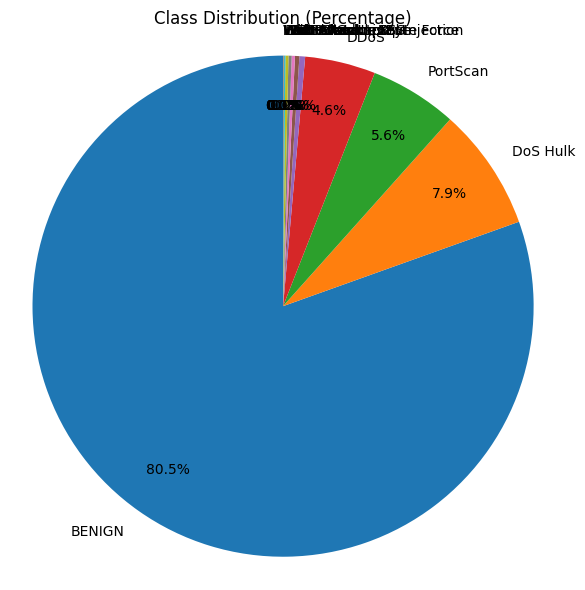

In [48]:
label_dist_pd = label_dist.to_pandas()

plt.figure(figsize=(6, 6))
plt.pie(
    label_dist_pd["len"],
    labels=label_dist_pd[label_col],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)
plt.title("Class Distribution (Percentage)")
plt.axis("equal")
plt.tight_layout()
plt.show()

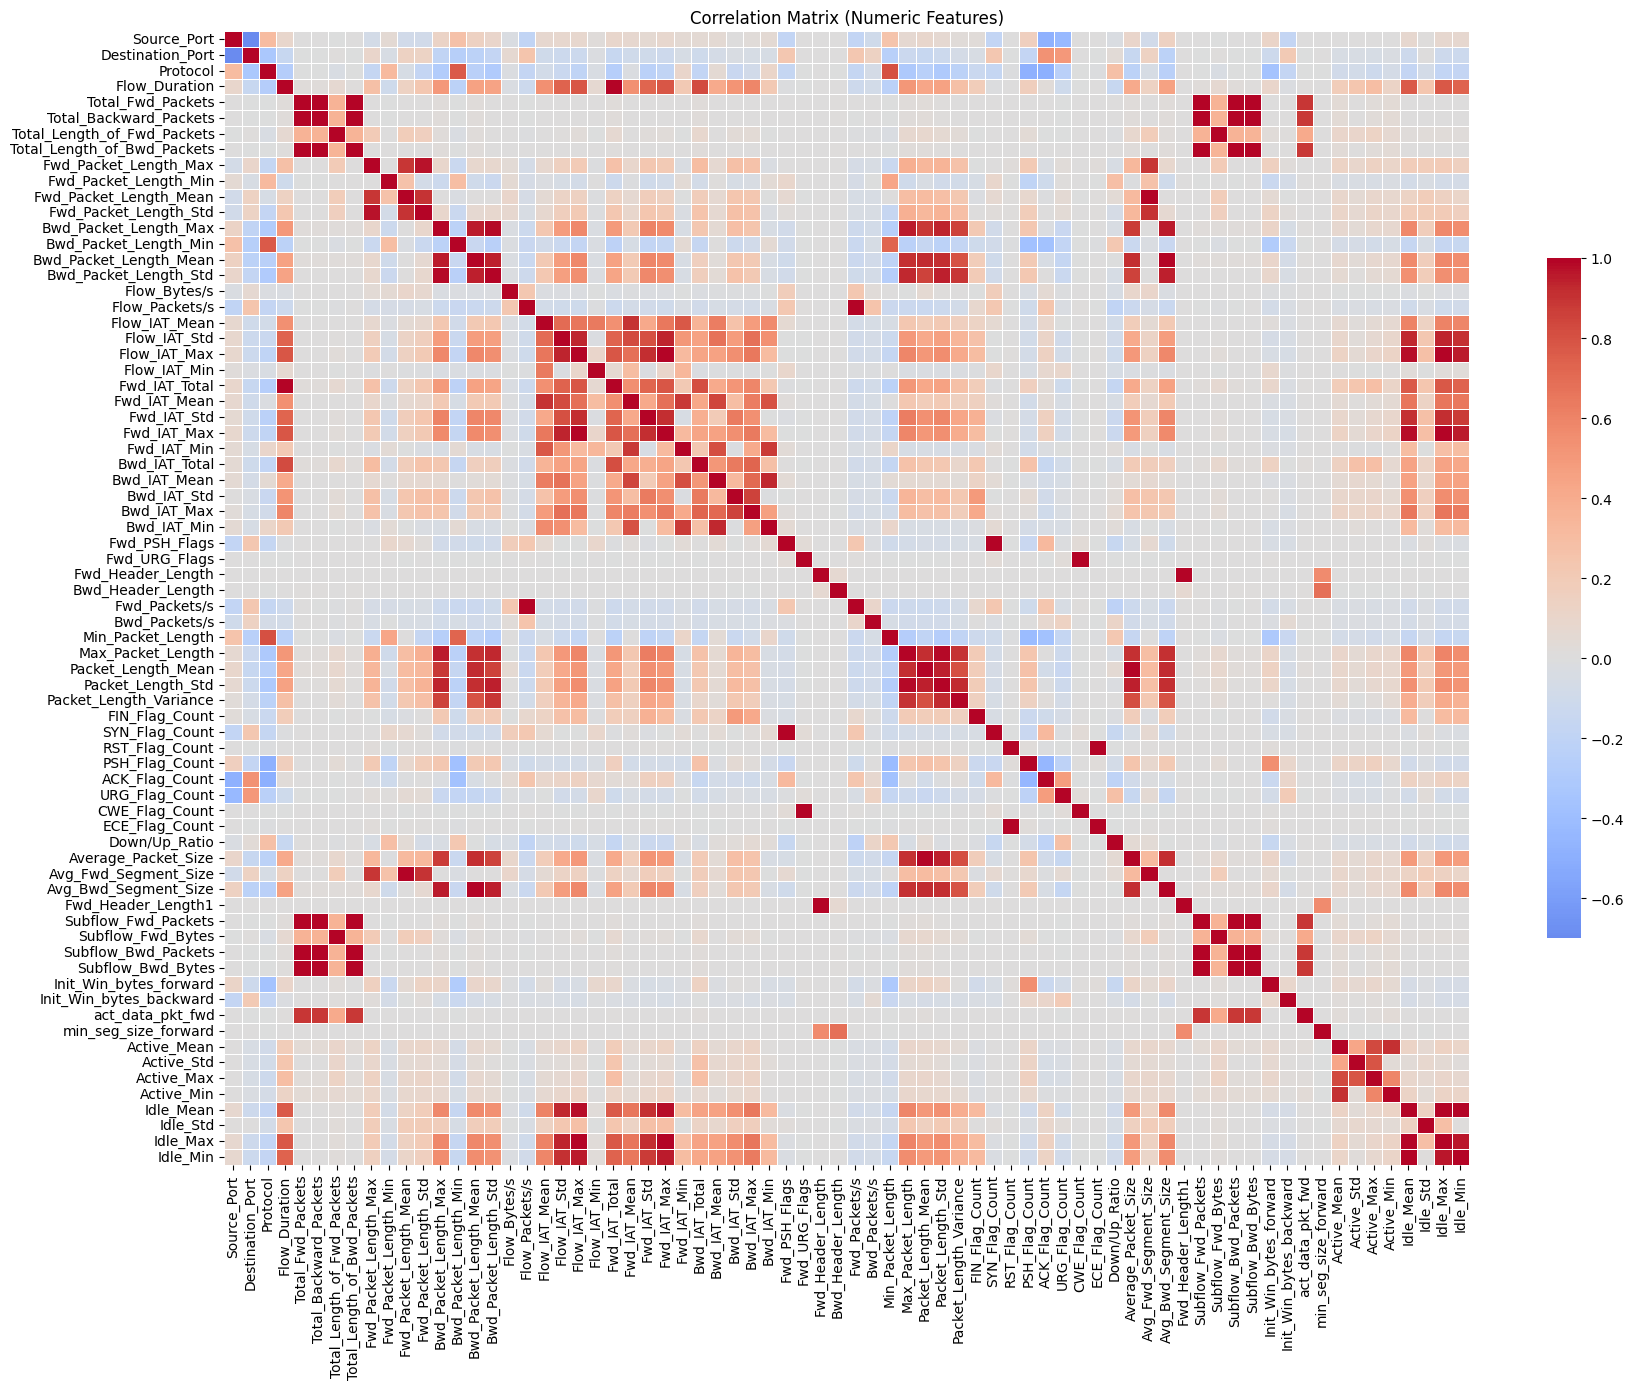

In [49]:
# Correlation Heatmap (Numeric Features)
# Convert only numeric subset for correlation
numeric_pd = df.select(numeric_cols).to_pandas()

corr = numeric_pd.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    cbar_kws={"shrink": 0.6}
)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

In [31]:
# Label encode the categorical column
df_encoded = df.with_columns(
    pl.col("Label").cast(pl.Categorical).to_physical().alias("label_encoded")
)

In [53]:
# ANOVA F-score: how well does each numeric col separate the label classes?
results = []
for col in df.select(cs.numeric()).columns:
    groups = [
        df.filter(pl.col("Label") == cls)[col].drop_nulls().to_list()
        for cls in df["Label"].unique().to_list()
    ]
    # Skip if any group is empty or has zero variance
    if any(len(g) == 0 for g in groups):
        continue
    f_stat, p_val = f_oneway(*groups)
    results.append({"column": col, "f_stat": f_stat, "p_value": p_val})

anova_df = pl.DataFrame(results).sort("f_stat", descending=True)
print(anova_df)

shape: (72, 3)
┌─────────────────────────────┬───────────────┬────────────┐
│ column                      ┆ f_stat        ┆ p_value    │
│ ---                         ┆ ---           ┆ ---        │
│ str                         ┆ f64           ┆ f64        │
╞═════════════════════════════╪═══════════════╪════════════╡
│ Bwd_Packet_Length_Std       ┆ 187760.841344 ┆ 0.0        │
│ Bwd_Packet_Length_Mean      ┆ 175951.867877 ┆ 0.0        │
│ Avg_Bwd_Segment_Size        ┆ 175951.867877 ┆ 0.0        │
│ Bwd_Packet_Length_Max       ┆ 172279.036988 ┆ 0.0        │
│ Packet_Length_Std           ┆ 155789.953744 ┆ 0.0        │
│ Fwd_IAT_Std                 ┆ 153504.701202 ┆ 0.0        │
│ Max_Packet_Length           ┆ 138017.050122 ┆ 0.0        │
│ Packet_Length_Variance      ┆ 132715.295114 ┆ 0.0        │
│ Idle_Min                    ┆ 130749.140672 ┆ 0.0        │
│ Idle_Mean                   ┆ 130187.175247 ┆ 0.0        │
│ Idle_Max                    ┆ 123413.945427 ┆ 0.0        │
│ Average

In [55]:
# Save Polars DataFrame as Parquet (all columns, compressed, fast)
df.write_parquet("cicids2017_after_EDA.parquet")
print("DataFrame saved to cicids2017_after_EDA.parquet")

DataFrame saved to cicids2017_after_EDA.parquet
